# Losowość na komputerze

dr Tomasz Wasak, prof. UMK  
Uniwersytet Mikołaja Kopernika w Toruniu  
Wydział Fizyki, Astronomii i Informatyki Stosowanej  
ul. Grudziądzka 5  
87-100 Toruń  
email: twasak@umk.pl

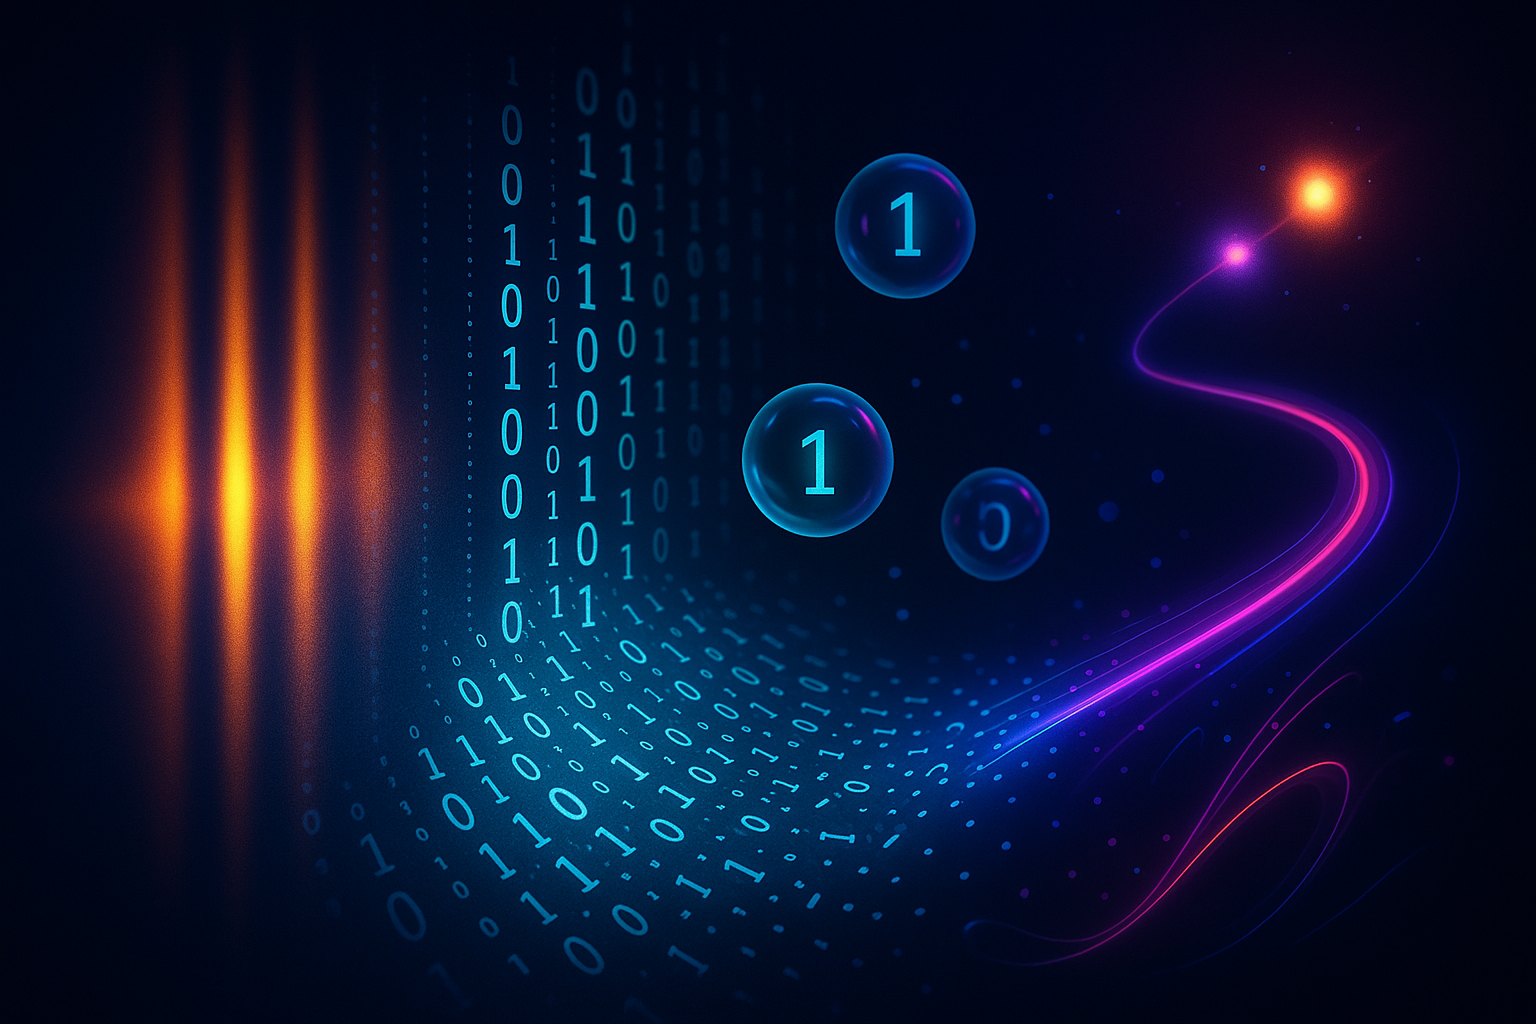

### Instrukcja obsługi

Każdą komórkę można kliknąć i nacisnąc przycisk "Run" albo nacisnąć kombinację klawiszy *Shift+Enter*.  
Uruchomiony zostanie program, który po zakończeniu działania przedstawi jakiś wynik.  
W programach można zmieniać wszystko, aby sprawdzić kiedy się popsują!

# 1. O zmiennych losowych

Komputery nie tylko pozwoliły na dokładne obliczenia i symulacje trudnych numerycznie zagadnień, lecz dały dostęp do analizy zjawisk, które rządzą się rachunkiem prawdopodobieństwa. Na przykład u podstaw mechaniki kwantowej leżą zjawiska, które oparte są o losowość.

Sprawdźmy, jak można na komputerze generować i opisywać zjawiska losowe.

## 1.1 Zmienna binarna

Wyobraźmy sobie losowy ciąg liczb 0 i 1.  
Mógłby wyglądać tak:

In [ ]:
# Importujemy maszynkę do generowania liczb losowych w Pythonie, tj. moduł numpy
# jest też moduł scipy, ale dla prostoty wykorzystamy tutaj numpy
import numpy as np

# Obiekt, który generuje liczby losowe ma bardzo 'przyjazną' nazwę "random.default_rng".
# Ustawiamy tzw. "seed", który jest daną wejściową, na podstawie której generowane są liczby.
# Naszą maszynkę nazwiemy "generator", ale nazwa mogłąby być dowolna.
# Można również nie ustawiać żadnego seedu, wtedy wybierze się automatycznie.
seed = 12345
generator = np.random.default_rng(seed)

# ustawiamy seed tylko dlatego, żebyście zobaczyli, to co ja. Możecie ustawić dowolną inną wartość.

Wylosujmy teraz kilka (tutaj 100) liczb.

In [ ]:
# Ustalmy najpierw ile chcemy wygenerować liczb
rozmiar_probki = 100

# Losowanie liczb wykorzstuje funkcję "integers" naszej maszynki "generator"
# Losujemy z przedziału [low,high) tj. dolny przedział ("low") się zawiera, górny wyłączony
# Dlatego ustawiamy low=0, a high=2, bo high się nie losuje, a więc, przedział [0,2) = 0,1 bez 2.
probka = generator.integers(low=0, high=2, size=rozmiar_probki)

Zobaczmy jak wygląda nasza próbka.

In [ ]:
probka

Narysujmy to, żeby zobaczyć jak wygląda.

In [ ]:
# Potrzebujemy modułu do rysowania
import matplotlib.pyplot as plt

plt.plot(probka, ".")
plt.show()

In [ ]:
plt.hist(probka, bins=[-0.1,0.1,0.9,1.1])
plt.show()

Przydatna charakterystyka danych w Pythonie. Jaki jest rozmiar danych (`size`) w poszczególnych wymiarach (`shape`)?

In [ ]:
# kształt danych,
print("Kształt = ", probka.shape)

# rozmiar danych
print("Rozmiar = ", probka.size)

# ile zajmuje to w bajtach?
print("Bajtów: ", probka.nbytes)
print("Bajtów: ", probka.size * probka.itemsize)

## 1.2 Charakterystyka losowych wielkości

Strategia postępowania z ekperymentami (na przykład takimi na komputerach), w których pojawią się liczby losowe jest następująca. Powtarzamy dany eksperyment wiele razy, a z otrzymanych danych staramy się uzyskać jakieś wielkości, które mają sens i pozwolą nam scharakteryzować te dane.

Wprowadźmy teraz **ważne wielkości**, które pozwalają na analizę danych.

**Średnia**:
$$\langle x \rangle = \frac{1}{N}( x_1 + x_2 + \ldots + x_N) = \frac{1}{N}\sum_i x_i$$

**Kwadrat średniej**:
$$\langle x^2 \rangle = \frac{1}{N}\sum_i x_i^2$$

**Wariancja**:
$$\mathrm{Var}(x) = \left\langle \big(x-\langle x \rangle\big)^2 \right\rangle = \langle x^2\rangle - \langle x \rangle^2$$

**Odchylenie standardowe**:
$$\sigma_x = \left\langle \big(x-\langle x \rangle\big)^2 \right\rangle\!{}^{1/2}  =  \sqrt{\mathrm{Var}(x)}$$

Zobaczmy jak to działa na przykładzie liczb 0 i 1.

In [ ]:
# losujemy próbkę
rozmiar_probki = 1000
probka = generator.integers(low=0, high=2, size=rozmiar_probki)

probka[0:39]

In [ ]:
# policzmy średnią i wariancję
srednia = np.mean(probka)
wariancja = np.std(probka)**2
var = np.var(probka)

srednia, wariancja, var

In [ ]:
# policzmy z definicji wariancję <x^2> - <x>^2 = < ( x - <x> )**2 >

wynik_losowy = np.sum(((probka - np.mean(probka))**2))/probka.size

wynik_teoretyczny = 0.5**2 # teoretyczna wartość to 0.25

print(f"Wynik losowy = {wynik_losowy}")
print(f"Wynik teoretyczny (ścisły) = {wynik_teoretyczny}")

In [ ]:
odch_std = np.std(probka)
print(f"Odchylenie standardowe {odch_std}")

# odchylenie standardowe mowi o rozrzucie danych wokol wartości średniej
print(f"Przedział: [{srednia - odch_std}, {srednia + odch_std}]")

## 1.3 Dlaczego prawie wszędzie w naturze są rozkłady Gaussowskie? Centralne twierdzenie graniczne

Zobaczmy co się stanie, jeżeli wylosujemy $N$ liczb losowych 0 lub 1 i je dodamy.
$$X = x_1 + x_2 + \ldots + x_N  = \sum_{i=1}^N x_i $$

In [ ]:
# ustalmy ile chcemy liczb losowych
N = 60

# generujemy ciąg N liczb losowych 0 lub 1
seq = generator.integers(low=0,high=2, size=N)
print("Wylosowaliśmy: ", seq)
print("suma = ", np.sum(seq))

Powtórzmy to wiele, wiele razy...  
Tutaj $10^5 = 100\, 000$ razy.

In [ ]:
N_powtorzen = 10**5

# tworzymy pusty kontener na dane
dane = np.empty(shape=N_powtorzen)

# powtarzamy losowanie przy pomocy instrukcji for
for i in range(1, N_powtorzen):
    # generujemy N liczb (domyślnie 20)
    seq = generator.integers(low=0,high=2, size=N)
    #  sumujemy wszystkie wygenerowane liczby i zapisujemy je w kontenerze na i-tym miejscu
    dane[i] = np.sum(seq)

In [ ]:
# zobaczmy jak wygląda pierwsze 250 danych
plt.plot(dane[:250], ".k") # ".k" oznacza "narysuj kropki (.) w kolorze czarnym (k)"
plt.xlabel("k-ta liczba")
plt.ylabel("Wartość sumy liczb, X")
plt.show()

In [ ]:
# zliczmy ile razy pojawiła się dana liczba X
plt.hist(dane, bins=10, density=False)
plt.xlabel(r"suma liczb, $X$")
plt.ylabel(r"Liczba zliczen")
plt.show()

In [ ]:
# Jaki to kształ?
# Zdefiniujmy rozkład gaussowski

def f(x, mean, sigma):
  return np.exp(-(x-mean)**2 / (2 * sigma**2)) / np.sqrt(2 * np.pi * sigma**2)

In [ ]:
# próbkujemy funkcję f(x), tj. tworzymy ciąg par liczb (x1, f(x1)), (x2, f(x2)), ...
# a potem go narysujemy na wykresie

xs = np.linspace(15,50,70) # to tworzy dane (x1, x2, x3, ..., xN), gdzie x1=0, xN=20, N=40
fs = f(xs, 0.5* N, 0.5*np.sqrt(N))


plt.hist(dane, bins=18, density=True)
plt.plot(xs, fs)
plt.xlabel(r"suma $x_i$, $X$")
plt.ylabel(r"Prawdopodobienstwo")
plt.show()

## 1.4 Korelacje - najprostszy opis zmiennych losowych

Zróbmy teraz eksperyment. Jak z losowości wydobyć prawidłowości?

Wylosujmy najpierw kilka ciągów $N$ liczb.

Ustalmy na przykład 10.

Losujemy więc

$$X_1,\ X_2,\ X_3,\ \ldots,\ X_8,\ X_9,\ X_{10}$$
Każda liczba $X_i$ może mieć wartość 0 lub 1.

Pytania:
* Czy jest jakaś zależność pomiędzy liczbą $X_1$ oraz liczbą $X_2$ albo $X_k$?
* Jak to sprawdzić?

In [ ]:
# Ustalmy N liczb, i powtórzmy losowanie N_powtorzen razy.
N = 10
N_powtorzen = 100000

# Losujemy!
dane = generator.integers(low=0, high=2, size=(N_powtorzen, N))
print("Kształt danych: dane.shape = ", dane.shape )

print("Kilka przykładów:")
for i in range(0,10):
  print(i, ": ", dane[i])
print(": :   ...")

Policzymy średnią wartość oraz odchylenie standardowe

In [ ]:
# policzmy średnią w zero-wym i n-tym punkcie
def srednie(data, n):
  mean_0 = np.mean(data[::, 0]) # punkt zerowy
  mean_n = np.mean(data[::, n]) # punkt n-ty
  return mean_0, mean_n

In [ ]:
srednie(dane, 3)

**Korelacja**

Liczymy teraz **korelację**:
$$ g_n = \big\langle \big( X_0 - \langle X_0\rangle \big) \big( X_n - \langle X_n\rangle \big) \big\rangle$$

Uwagi:
* Jeśli zmienne $X_0$ i $X_n$ są niezależne, to korelacja jest zero, $g_n=0$.
* Jeśli korelacja jest niezerowa, to między zmiennymi jest jakaś zależność.

In [ ]:
# policzmy korelację pomiędzy n-tym punktem a zero-wym
# to jest funkcja g_n z wzoru powyżej

def corr(data, n):
  mean_0 = np.mean(data[::, 0]) # punkt zerowy
  mean_n = np.mean(data[::, n]) # punkt n-ty
  wynik = np.mean((data[::,0] - mean_0)*(data[::,n] - mean_n))
  return wynik

In [ ]:
# zobaczmy jak wygląda korelacja w funkcji n
# tworzymy tablicę zmieniając n = 0,1,2,3... we wzorze na g_n = corr(data,n)

corrs = [ corr(dane, n) for n in range(0,N)]


# rysujemy wynik:
import matplotlib.pyplot as plt
plt.plot(corrs, "o-"),
plt.plot(range(0,N), [0]*N,"-", color="gray")
plt.xlabel("Indeks n")
plt.ylabel("Korelacja pomiędzy 0 i n-tą liczbą")
plt.show()

**Co jeśli podmienimy np. 6-tą liczbę?**

Powiedzmy, że bierzemy tę 6-tą liczbę. Zamiast niej podstawiamy w danym ciągu wartość 1-szej liczby.


In [ ]:
# kopujemy dane, żeby mieć porównanie
daneJoke = dane.copy()

# podstawiamy X_1 -> X_6:
# pamiętamy, że 6-ta liczba ma indeks 5, bo zaczynamy indeksowanie od zera

for i in range(len(daneJoke)):
  liczby = daneJoke[i]
  liczby[5] = liczby[0]

In [ ]:
# czy widzimy różnicę?

idx = generator.integers(len(dane))
print(f"Zobaczmy indeks: {idx}")
print(dane[idx])
print(daneJoke[idx])

In [ ]:
print("Jak wyglądają dane?")
for i in range(0,10):
  print(i, ": ", daneJoke[i])
print(": :   ...")

print("Czy widać tu jakaś nielosowość?")

Policzmy jednak korelację!

In [ ]:
# chcemy teraz narysować korelacje: g_0, g_1, g_2, ...

corrs = [ corr(dane, n) for n in range(0,N)]
corrsJoke = [ corr(daneJoke, n) for n in range(0,N)]

import matplotlib.pyplot as plt
plt.plot(corrs, "o-", label="dane oryginalne"),
plt.plot(corrsJoke, "o-.r", label="dane podmienione"),
plt.plot(range(0,N), [0]*N,"-", color="gray")
plt.xlabel("Indeks n")
plt.ylabel("Korelacja pomiędzy 0 i n-tą liczbą")
plt.legend()
plt.show()

# 2. Ćwiczenia z liczbami losowymi

## 2.1 Błądzenie losowe

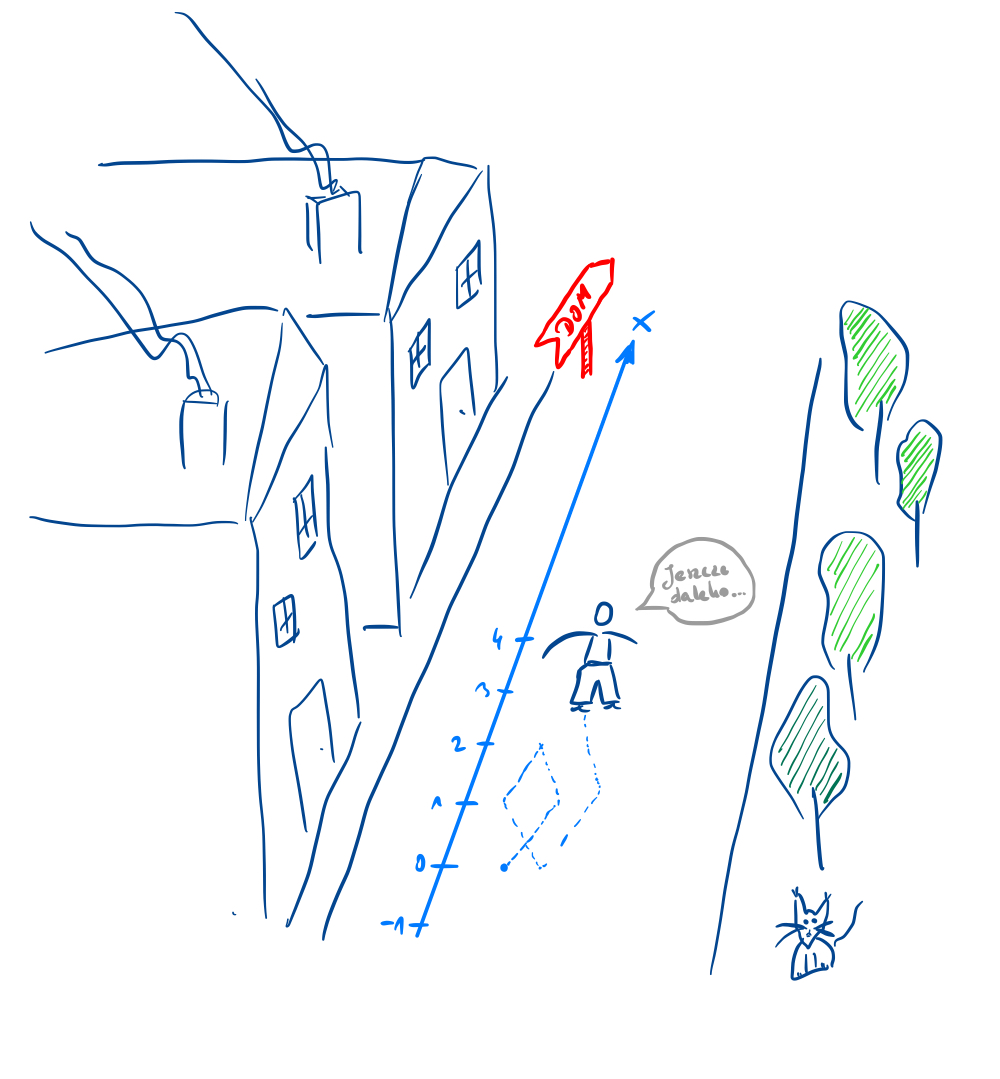

Wyobraźmy sobie studenta lub studentkę, który tak bardzo się cieszył, że zdał trudny egzamin podczas sesji, że postanowił uczcić swoje osiągnięcie. Wraca teraz do domu idąc ulicą, ale kroki z trudem stawia i nie bardzo wie, w którą stronę iść, ponieważ jest tak zmęczony. Czasem stawia więc krok do przodu, a czasem krok do tyłu...

Pytanie, jak daleko dojdzie?....

Spróbujmy to oszacować, gdzie znajdzie się po $n$ krokach.

Oznaczmy:
* $d$ - długość kroku
* $X_k = \pm d$ - $k$-ty krok, jeśli dodatni, to idzie do przodu, jeśli ujemny to do tyłu
* $s_n = X_0 + X_1 + \ldots + X_n$ - całkowity dystans po $n$ krokach

$X_k$ jest zmienną losową, ponieważ nie wiemy, w którą stronę osoba postawi krok.

In [ ]:
# długość kroku
d = 1.0 # np w metrach

# wylosujmy n kroków
n_krokow = 100

# zobaczmy poniżej, że losujmey 0 lub 1, chcemy jednak, żeby wartości losowe wynosiły -1 lub 1. Możemy to łatwo uzyskać stosując transformację: {0,1} = x -> y = 2 x - 1 = {-1, 1}
kroki = generator.integers(low=0, high=2, size=n_krokow)
kroki = 2*kroki -1
kroki = d*kroki  # nadajemy skalę: jeden krok odowiada dystansowi d

kroki

In [ ]:
# Jak daleko dojdzie po n krokach?
dystans_n = np.sum(kroki)

print(f"Osoba zrobiła {n_krokow} kroków, a pokonała dystans {dystans_n} metrów.\nCzy to dużo?")

Zbadajmy to zagadnienie dokładniej. Stwórzmy najpierw funkcję, która generuje dystans po $n$ krokach.

In [ ]:
# generujemy dostans przebyty aż do n kroków

def trajektoria(n, d):
  kroki = generator.integers(low=0, high=2, size=n)
  kroki = 2*kroki -1
  kroki = d*kroki

  return np.concatenate((np.array([0.,]), np.cumsum(kroki)))


In [ ]:
trajektoria(10, d)

Zrozumiemy zagadnienie, a więc na czym polega zjawisko, jeżeli przyjrzymy się wielu takim osobom. Każdy jest inny, ale tylko powtarzając jakieś zjawisko, możemy zrozumieć leżace u podstaw mechanizmy.

In [ ]:
# załóżmy, że każdą osobę obserwujemy przez n_kroków (tu np. 30)
# załóżmy, że obserwujemy konkretną liczbę osób (np. tutaj ile_osob=10)

n_krokow = 30
ile_osob = 10
trajektorie_wiele_osob = [trajektoria(n_krokow, d) for n in range(ile_osob)]

In [ ]:
print(f"Osoba numer 0: {trajektorie_wiele_osob[0]}")
print(f"Osoba numer 1: {trajektorie_wiele_osob[1]}")
print(f"Osoba numer 2: {trajektorie_wiele_osob[1]}")

In [ ]:
import matplotlib.pyplot as plt

for i in range(ile_osob):
  plt.plot(trajektorie_wiele_osob[i], np.arange(n_krokow+1), ".-")
plt.xlabel("dystans [m]")
plt.ylabel("liczba kroków n")
plt.show()

Widzimy, że te osoby nie dochodzą bardzo daleko...
Przejdźmy teraz do takiej sytuacji, w której mamy wiele tysięcy takich osób.
I zapytajmy, ile osób osiągnęło po n krokach jakiś konkretny dystans.

In [ ]:
n_krokow = 100
ile_osob = 2000
trajektorie_wiele_osob = [trajektoria(n_krokow, d) for n in range(ile_osob)]
trajektorie_wiele_osob = np.array(trajektorie_wiele_osob)

In [ ]:
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
steps = 5
plt.hist(trajektorie_wiele_osob[::, steps], bins=np.arange(-40,40,0.5), align="left")
plt.xlabel("dystans")
plt.ylabel("liczba osób")
plt.title(f'Kroków: {steps}')


plt.subplot(2, 2, 2)
steps = 25
plt.hist(trajektorie_wiele_osob[::, steps], bins=np.arange(-40,40,0.5), align="left")
plt.xlabel("dystans")
plt.ylabel("liczba osób")
plt.title(f'Kroków: {steps}')

plt.subplot(2, 2, 3)
steps = 50
plt.hist(trajektorie_wiele_osob[::, steps], bins=np.arange(-40,40,0.5), align="left")
plt.xlabel("dystans")
plt.ylabel("liczba osób")
plt.title(f'Kroków: {steps}')

plt.subplot(2, 2, 4)
steps = 100
plt.hist(trajektorie_wiele_osob[::, steps], bins=np.arange(-40,40,0.5), align="left")
plt.xlabel("dystans")
plt.ylabel("liczba osób")
plt.title(f'Kroków: {steps}')

plt.tight_layout()
plt.show()


## 2.2 Proces "Błądzenie losowe" ("random walk")

Załóżmy, że osoba jednak ma jednak większą szansę na krok do przodu niż na krok w tył. Jak wygląda wtedy rozkład prawdopodobieństwa?

In [ ]:
# generujemy dostans przebyty aż do n kroków

def trajektoria_p(n, d, p):
  kroki = np.random.choice([-1,1], p =[1-p, p], size=n)
  kroki = d*kroki

  return np.concatenate((np.array([0.,]), np.cumsum(kroki)))


In [ ]:
n_krokow = 100
ile_osob = 2000

# prawdopodobieństwo ruszenia do przodu
p_val = 0.9

trajektorie_wiele_osob = [trajektoria_p(n_krokow, d, p_val) for n in range(ile_osob)]
trajektorie_wiele_osob = np.array(trajektorie_wiele_osob)

In [ ]:
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
steps = 5
plt.hist(trajektorie_wiele_osob[::, steps], bins=np.arange(-100,100,0.5), align="left")
plt.xlabel("dystans")
plt.ylabel("liczba osób")
plt.title(f'Kroków: {steps}')


plt.subplot(2, 2, 2)
steps = 25
plt.hist(trajektorie_wiele_osob[::, steps], bins=np.arange(-100,100,0.5), align="left")
plt.xlabel("dystans")
plt.ylabel("liczba osób")
plt.title(f'Kroków: {steps}')

plt.subplot(2, 2, 3)
steps = 50
plt.hist(trajektorie_wiele_osob[::, steps], bins=np.arange(-100,100,0.5), align="left")
plt.xlabel("dystans")
plt.ylabel("liczba osób")
plt.title(f'Kroków: {steps}')

plt.subplot(2, 2, 4)
steps = 100
plt.hist(trajektorie_wiele_osob[::, steps], bins=np.arange(-100,100,0.5), align="left")
plt.xlabel("dystans")
plt.ylabel("liczba osób")
plt.title(f'Kroków: {steps}')

plt.tight_layout()
plt.show()


In [ ]:
# zastaówmy się jeszcze jaka jest szerokość rozkładu po n krokach
# szerokość, czyli odchylenie od średniej, czyli używamy funkcji np.std

def szerokosc(n, trajektorie):
  dane = trajektorie_wiele_osob[::,n]
  return np.std(dane)


def srednia(n, trajektorie):
  dane = trajektorie_wiele_osob[::,n]
  return np.mean(dane)

In [ ]:
szerokosci = [szerokosc(n, trajektorie_wiele_osob) for n in range(n_krokow)]
srednie = [srednia(n, trajektorie_wiele_osob) for n in range(n_krokow)]

In [ ]:
ns = np.arange(n_krokow)

# diffusion coefficient
Dval = (p_val)*(1-p_val)

plt.plot(ns, szerokosci, ".", label="statistical data")
plt.plot(ns, 2.0*np.sqrt(Dval * ns), label=r"$2 \sqrt{D n}$")
plt.xlabel("liczba kroków n")
plt.ylabel("Szerokość rozkładu")
plt.legend(loc='upper left')
plt.xscale("linear")
plt.yscale("linear")
plt.show()

In [ ]:
ns = np.arange(n_krokow)

# średnia prędkość, zauważ że v<1
v = (2*p_val-1)
print(f"Średnia prędkość wynosi v = {v} d/krok")

plt.plot(ns, srednie, ".", label="dane statystyczne")
plt.plot(ns, (2*p_val-1) * ns , label="liniowy ruch, x = vt")
plt.plot(ns, ns , label=r"liniowy ruch, $x = v_\mathrm{max}t$", linestyle="dashed", c="k")

plt.xlabel("liczba kroków")
plt.ylabel("średni przebyty dystans")
plt.xscale("linear")
plt.yscale("linear")
plt.legend()
plt.show()

# 3. Generowanie liczb losowych z rozkładów

## 3.1 Płaski rozkład

Nauczmy się najpierw generować liczby losowe z przedziału [0,1]. Jest to bardzo użyteczne.

In [ ]:
import numpy as np

seed=12345
generator = np.random.default_rng(seed)

In [ ]:
# losujemy [0,1)

Nm = 1000000
rs = generator.uniform(0,1, size=Nm)

print("5 kolejnych wylosowanych liczb:")
print(rs[0:5])

In [ ]:
plt.hist(rs, bins=10, density=True)
plt.xlabel("Liczba losowa r")
plt.ylabel("Prawdopodobieństwo wystpienia liczby r")
print(rs[0:20])

## 3.2 Dowolny rozkład, metoda #1 - metoda inwersji

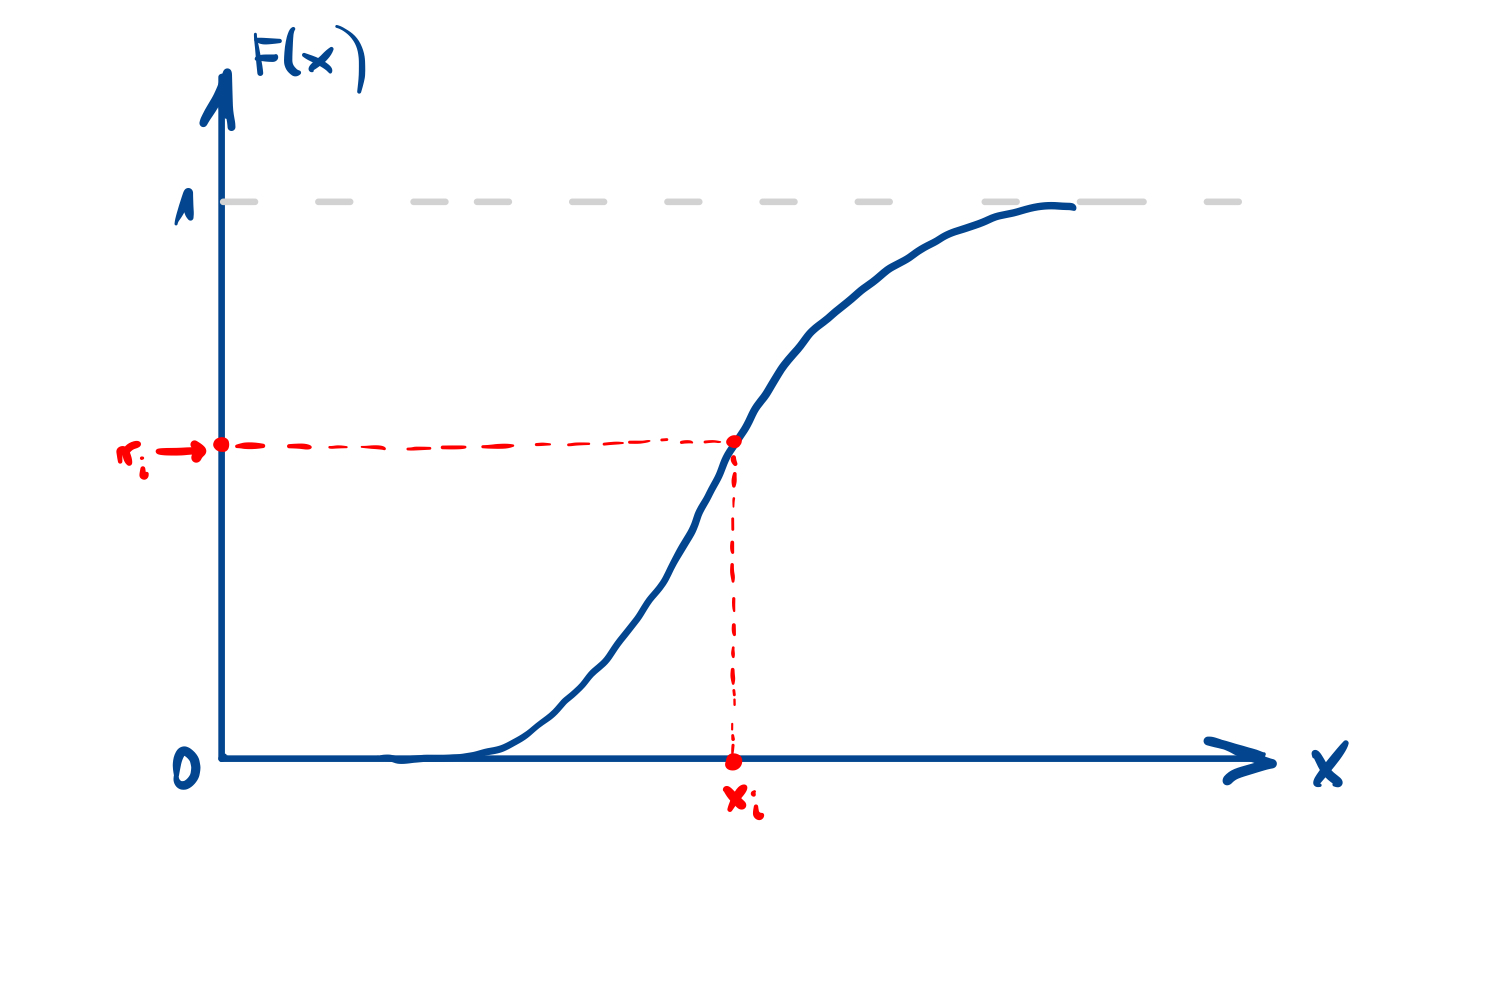

**Metoda**  

Mamy zadany rozkład $p(x)$.   
Taki rozkład spełnia $p(x)\geqslant0$ oraz $\int_{-\infty}^{\infty}p(x)dx = 1.$   
Wyznaczmay funkcję $F(x) = \int_{-\infty}^{x}p(z)dz$.   
Zauważmy, że $0 \leqslant F(x) \leqslant 1$.

Losujemy $r\in [0,1]$.
Znajdujemy $x$ takie, że $F(x) = r$.    
Wtedy $x$ są dane rozkładem $p(x)$.

**Przykład**

Zobaczmy jak to działa. Weźmy $p(x) = 2x $ na przedziale $[0,1]$.


Sprawdźmy, że $\int_{0}^1 2x dx = x^2 \big|^{x=1}_{x=0} = 1$.

Wyznaczamy $F(x) = \int_{0}^x 2s ds = x^2$.

Rozwiązujemy więc $r = F(x)$ i znajdujemy $x = \sqrt{r}$.

Sprawdźmy!

In [ ]:
# nasz rozkłąd
def rozklad(x):
  return 2*x

# generujemy losowe x na podstawie losowych r z przedziału [0,1)
def genX(r):
  return np.sqrt(r)

In [ ]:
Nm = 100000
rs = generator.uniform(0,1,size=Nm)

xs = genX(rs)

In [ ]:
plt.hist(xs, density=True, bins=50,label="wygenerowany rozkład")
plt.plot(np.linspace(0,1,100), rozklad(np.linspace(0,1,100)), label="p(x)")
plt.legend()
plt.show()

## 3.3 Dowolny rozkład, metoda #2 - metoda odrzucania

Metoda bazuje na geometrycznej interpretacji rozkładu prawdopodobieństwa. Zakładamy, że nasz rozkład prawdopodobieństwa $p(x)$ jest ograniczony $x\in[a,b]$ oraz $p(x) \leqslant c$ ma maximum równe $c$.

Procedura:
1. Zamknij $p(x)$ w prostokącie ograniczonym przez $x=a$, $x=b$, $y=0$ oraz $y=c$. Rozmiar prostokąta $(b-a) \times c$.
2. Wylosuj teraz punkt $p = (x,y)$, aby znajdował się w prostokącie. Wylosuj takich punktów bardzo dużo, aby jednorodnie pokryły prostokąt.
Jeśli prostokąt jest duży, potrzebujemy baaaardzo dużo punktów.
3. Jeśli dany punkt $(x,y)$ jest taki, że $y\leqslant p(x)$, tzn. leży pod krzywą (punkty czerwone), to $x$ zaakceptuj. W przeciwnym razie odrzuć.

Zaakceptowane punkty $x$ (czerwone) mają rozkład $p(x)$.

Zobaczmy jak to działa.

In [ ]:
# chcemy wygenerować x dane rozkładem p(x) = sin(x) dla 0<x<pi

x_tab = np.linspace(0,np.pi, 50)
y_tab = np.sin(x_tab)


# losujemy liczby
Nm = 10**3
xs = generator.uniform(0, np.pi, size=Nm)
ys = generator.uniform(0, 1, size=Nm)

# mamy pary (x,y)
# dla każdego y wybieramy x tylko wtedy, gdy y <= sin(x)
# wbrany zbiór x nazywamy Xs
sins = np.sin(xs)
Xs = xs[ys<=sins]


plt.plot(xs, ys, ".")
plt.plot(x_tab, y_tab, "-k")
plt.show()

In [ ]:
# a teraz odrzucamy wszystko co leży ponad krzywą czarną

plt.plot(Xs,ys[ys<=sins],".r")
plt.plot(x_tab, y_tab, "-k")
plt.show()

In [ ]:
plt.hist(Xs, bins = 21, density=True)
plt.plot( np.linspace(0,np.pi), 0.5*np.sin(np.linspace(0,np.pi)), label="0.5*sin(x)")
plt.show()

# 4. Ćwiczenia z liczbami losowymi - generowanie

## 4.1 Rozkład wykładniczy - ćwiczenie

Często czas $t \geqslant 0 $ pomiędzy jakimiś wydarzeniami jest opisany rozkładem wykładniczym. Jak go wylosować?

Rozkład prawdopodobieństwa jest opisany przez $p(t) = \lambda e^{- \lambda t}$, gdzie $\lambda$ jest skalą zaniku (wymiar 1/czas).

Użyj metody inwersji.

In [ ]:
# wpisz tu swój kod
# ...
# ...
# ...

## 4.2 Rozkład dyskretny $\{0,1\}$ z prawdopodobieństwem $\{p, 1-p\}$

Wykorzystując metodę inwersji wygeneruj liczby 0 z pradopodobieństwem $p$
oraz liczby 1 z prawdopodbieństwem $1-p$.

In [ ]:
# wpisz tu swój kod
# ...
# ...
# ...

### Rozwiązanie

In [ ]:
pval = 0.8

def cdf(r, pval):
  if r <= pval:
    return 0
  elif r > pval:
    return 1

# generujemy zbiór { r } and { cdf(r) }
rs = generator.uniform(0,1,size=10000)
ys = np.array(list(map( lambda x: cdf(x, pval), rs)))

# histogram
plt.hist(ys, density=True, bins=[0,1,2], align="left")
plt.xlim(-1,2)
plt.ylim(0,1)
plt.show()

## 4.3 Rozkład na sferze

Mając do dyspozycji liczby losowe, możemy użyć ich do wygenerowania punktów na sferze.

Punkt na sferze możemy sparametryzować poprzez punkt na sferze:
$\mathbf{r} = (\sin\theta \cos\phi, \sin\theta \sin\phi, \cos\theta)$.

Zobaczmy, że dla dowolnych kątów $(\theta,\phi)$ wektor $\mathbf{r}$ jest unormowany $\mathbf{r}^2 = 1$.

Aby pokryć całą sferę, wylosujemy liczby losowe $\theta \in [0,\pi)$ oraz $\phi \in [0,2\pi)$.

Zobaczmy jak to wygląda.

In [ ]:
# losujemy kąty theta

import numpy as np

seed=12345
generator = np.random.default_rng(seed)

# ile punktów w każdym wymiarze?
Ntheta, Nphi = 2000, 2000
thetas = generator.uniform(0, np.pi, size=Ntheta)
phis = generator.uniform(0,2*np.pi, size=Nphi)

Jak punkty leżą na płaszczyźnie $(\theta,\phi)$?

In [ ]:
plt.plot(thetas,phis, ".")
plt.xlabel(r"$\theta$")
plt.xlabel(r"$\phi$")
plt.show()

Wyglądają na dość jednorodnie rozłożone w płaszczyźnie.

Ale jak wyglądają na sferze?

Sprawdźmy!

In [ ]:
def position(angle):
  theta, phi = angle
  out = np.array([
    np.sin(theta) * np.cos(phi),
    np.sin(theta) * np.sin(phi),
    np.cos(theta)])
  return out

In [ ]:
# generujemy pozycje na sferze (x,y,z)
points = zip(thetas,phis)
ps = map(position, points)
ps = np.array(list(ps))

In [ ]:
# narysujmy 3d
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(projection='3d')
ax.set_box_aspect((1,1,1))  # ustaw rozmiary pudełka 1:1:1

ax.scatter(ps[:,0], ps[:,1], ps[:,2],".")
plt.show()

Widoczne jest zgrupowanie punktów wokół biegunów...
Jak to usunąć?

Okazuje się, że ważne jest generowanie kąta $\theta$ danego rozkładem $\sin\theta$.

Dlaczego?

Otóż całka po sferze, która ma wyrażać średnią z jakiejś funkcji, tzn.
$$\langle f(\mathbf{r})\rangle = \iint_{\mathrm{sfera}}d^2r f(\mathbf{r})$$
w zmiennych biegunowych $(\theta,\phi)$ przyjmuje postać
$$\langle f(\mathbf{r})\rangle = \int_{0}^\pi d\theta \int_{0}^{2\pi}\!\! d\phi\,  \sin\theta f(\mathbf{\theta,\phi}).$$
Otrzymujemy więc dodatkowy $\sin\theta$, którego nie uwzględniliśmy!

Zobaczmy, co się stanie, jak go uwzględnimy.

In [ ]:
Ntheta, Nphi = 2000, 2000
thetas = np.arccos(generator.uniform(-1, 1, size=Ntheta))
phis = generator.uniform(0,2*np.pi, size=Nphi)


plt.plot(thetas,phis, ".")
plt.xlabel(r"$\theta$")
plt.xlabel(r"$\phi$")
plt.show()

In [ ]:
# generujemy pozycje na sferze (x,y,z)
points = zip(thetas,phis)
ps = map(position, points)
ps = np.array(list(ps))

# narysujmy 3d
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(projection='3d')
ax.set_box_aspect((1,1,1))  # ustaw rozmiary pudełka 1:1:1

ax.scatter(ps[:,0], ps[:,1], ps[:,2],".")
plt.show()

Wygląda dużo lepiej!

## 4.4 Obliczanie liczby $\pi$


Chcemy policzyć $I = \iint_\mathrm{koło} d^2r = \pi r^2$.
Zapisujemy $\iint_\mathrm{koło} d^2r = \iint_\mathrm{koło} d^2r f(x,y)$,
gdzie $f(x,y) = 1$ jeśli punkt $(x,y)$ jest w kole, oraz $f(x,y) = 0$ jeśli punkt $(x,y)$ jest poza kołem.
Teraz możemy rozciągnąć całkowanie na obszar kwadratu K: $-L \leqslant x,y \leqslant L$. I zapisać, że
$$I = \iint_K f(x,y) d^2r = (2r)^2 \iint_K f(x,y) \frac{1}{(2r)^2} d^2r$$
Oznacza to, że liczymy średnią:
$$I = (2L)^2 \langle f(x,y )\rangle$$
gdzie rozkładem jest jednorodny rozklad
$$p(x,y) = \frac{1}{(2L)^2}.$$

Pamiętając, że $I = \pi r^2$, możemy metodą losowania wyznaczyć liczbę $\pi$ dla $r=1$:
$$\pi = (2L)^2 \langle f(x,y )\rangle$$



**Sprawdźmy jak to działa.**

Chcemy policzyć pole koła o promieniu $L=1.1$.
Losujemy liczby losowe w kwadracie $-L \leqslant x \leqslant L$ i $-L \leqslant y \leqslant L$, w którym koło się zawiera.

Akceptujemy tylko te punkty, które wpadają do koła.

In [ ]:
# Definiujemy funkcję f(x,y) = 1 na kole i 0 poza kołem:
def f(x,y):
  if x**2+y**2 <= 1:
    return 1.0
  else:
    return 0.

In [ ]:
# losujemy punkty z kwadratu K

Nm=10**3
L = 1.1
xs = L*generator.uniform(-1,1,size=Nm)
ys = L*generator.uniform(-1,1,size=Nm)

pts = np.empty(len(xs))
for i in range(len(xs)):
  pts[i] = f(xs[i],ys[i])

In [ ]:
pi_est = 4 * L**2 * pts.mean()

print(f"Liczba pi wynosi = {pi_est}")
print(f"Błąd obliczenia pi wynosi = {4 * L**2 * pts.std()/np.sqrt(Nm)}")
print(f"Błąd obliczenia pi - pi_est = {np.pi - pi_est}")

In [ ]:
# Zdefiniujmy teraz generator liczby pi

def gen_pi(Nm, L=1):
  xs = L*generator.uniform(-1,1.,size=Nm)
  ys = L*generator.uniform(-1,1.,size=Nm)

  pts = np.empty(len(xs))
  for i in range(len(xs)):
    pts[i] = f(xs[i],ys[i])

  return 4 * L**2 * pts.mean()

In [ ]:
# wylosujmy dużo liczb pi, aby zobaczyć jaki popelniamy błąd

many_pi = [gen_pi(10**5, 1.1) for i in range(50)]

# nasze oszacowanie liczby pi
pi_wynik = np.mean(many_pi)

plt.hist(many_pi)
print(f"Średnia z obliczonych liczb pi = {pi_wynik}.")
print(f"Oszacowany błąd obliczenia liczby pi = {np.std(many_pi)}.")
print(f"Błąd = {pi_wynik - np.pi}.")

In [ ]:
# jakie punkty bierzemy do zliczenia liczby 1 (niebieskie) a jakie nie (czerowne)?
# Pamietamy, że pts=1 jeśli wewnatrz, pts=0 jesli na zewnatrz
inside=pts>0.5
outside=pts<0.5 

plt.plot(xs[inside],ys[inside], "b.")
plt.plot(xs[outside],ys[outside], "r.")
plt.axis('equal')
plt.show()

# 5. Obca cząstka w ośrodku - ruchy Browna

Wyobraźmy sobie, że w płynie umieszczone zostało ziarenko pyłku kwiatu. Czy coś można powiedzieć o ruchach takiego ziarenka?

Ruch takiego pyłku opisuje równanie Langevina:
$$ \frac{d^2}{dt^2}{x(t)} + \gamma \frac{d}{dt}{x(t)} = \xi(t),$$
gdzie $\gamma$ jest związana z lepkością cieczy i dyssypacją energii, a $\xi$ to siła działająca na pyłek.
Przyjmujemy tu jednostkową masę ciała $m=1$, dlatego nie pojawia się w równaniu Newtona.

Siła jest siłą losową, która pochodzi od zderzeń pyłku z cząstkami otaczającego go płynu.
Jej funkcja korelacji
$$ \langle \xi(t)\xi(t')\rangle = 2 \gamma k_B T \delta(t-t'). $$

Zauważmy, że losowa siła odpowiada za fluktuacje położenia i prędkości, ale pojawia się w niej również współczynnik $\gamma$. Jest to przejaw twierdzenia fluktuacyjno-dyssypacyjnego, które łączy losową siłę oraz dyssypację energii w układzie.

Jak to rozwiązać?


Zapiszmy równania najpierw, wprowadzając $dx(t)/dt = v(t)$ prędkość, jako:
$$
Y(t) = \begin{pmatrix}
x(t) \\
v(t)
\end{pmatrix}
$$

Możemy wtedy zapisać
$$\frac{d Y(t)}{dt} = A \cdot Y(t) +
\begin{pmatrix}
0 \\
\xi(t)
\end{pmatrix}
$$.

Najprościej można to rozwiązać dyskretyzując równanie dla kroków $n\cdot \Delta t$:
$$Y_{n+1} = Y_n + A\cdot Y_n + W_n.$$
Okazuje się, że $W_n$ i $W_{n'}$ są gaussowskie, niezależne oraz $\langle W_n\rangle=0$ i $\langle W_n^2\rangle= 2 \gamma k_B T \Delta t$.

In [ ]:
# Oznaczmy Y(t) = [x(t), v(t)]
# Pamiętajmy, że Y to nie jest wektor kolumnowy.

seed=12345
generator = np.random.default_rng(seed)


def propagate(steps, dt, x0, v0, gamma, Gamma):
  Y = np.array([x0, v0])
  A = np.array([[0,1],[0, -gamma]])

  xis = np.sqrt(dt*Gamma)*generator.normal(0,1, size=steps)
  Ys = np.empty(shape=(steps+1, 2))
  Ys[0] = [x0,v0]

  for i in range(steps):
    Ys[i+1] = Ys[i] + Ys[i]@ (A.transpose()) * dt + np.array([0, xis[i]])

  return Ys

In [ ]:
dt = 0.01
x0 = 0.0
v0 = 0.0
gamma = 2.0
Temp = 10.0
Gamma = 2*gamma*Temp
steps = 300

trajs = [ propagate(300, dt, x0, v0, gamma, Gamma) for n in range(1000)]

In [ ]:
NPtrajs=np.array(trajs)

In [ ]:
NPtrajs[0,0:10]

In [ ]:
ts = np.arange(NPtrajs.shape[1])*dt
print(f"Final time t = {ts[-1]}")

import matplotlib.pyplot as plt

for i in range(0,10):
  plt.plot(ts, NPtrajs[i,:,0])
plt.xlabel("Czas t")
plt.ylabel("Położenie x")
plt.title("Położenie x(t)")
plt.show()

In [ ]:
for i in range(0,10):
  plt.plot(ts, NPtrajs[i,:,1])
plt.xlabel("Czas t")
plt.ylabel("Prędkość v")
plt.title("Prędkość v(t)")
plt.show()

In [ ]:
from scipy import stats

gs = stats.norm
def dist(v):
  return gs.pdf(v, loc=0, scale=np.sqrt(Temp))

In [ ]:
vs = np.linspace(-10,10,100)
plt.hist(NPtrajs[:,10,1], density=True, alpha=0.5, bins=20, color="r")
plt.hist(NPtrajs[:,-1,1], density=True, alpha=0.5, bins=20, color="b")
plt.plot( vs,  dist(vs), label="Rozkład terminczny @ T")
plt.legend()

plt.xlim(-10,10)

plt.xlabel("Prędkość v")
plt.ylabel("Rozkład prędkości")
plt.title("p(v|t)")
plt.show()

In [ ]:
plt.hist(NPtrajs[:,40,0], density=True, bins=20, alpha=0.5, color="r")
plt.hist(NPtrajs[:,100,0], density=True, bins=20, alpha=0.5, color="g")
plt.hist(NPtrajs[:,-1,0], density=True, bins=20, alpha=0.5,  color="b")

plt.xlabel("Położenie x")
plt.ylabel("Rozkład położenia")
plt.title("p(x|t)")
plt.show()